In [1]:
# 경사하강법
    # 모델이 얼마나 틀렸는지 점수를 매기는 손실 함수 -> 오답이 많을수록 값이 커짐
        # 손실함수 값이 최소(궁극적 목적은 0)

# 미분값(기울기) 예시 = (온도변화량 100) / (손잡이 움직인 양 1) = 100
# 미분값(기울기) 예시 = (온도변화량 100) / (손잡이 움직인 양 1) = 1

# 확률적

# 학생이 공부한 시간 x1, 문제집 푼 갯수 x2를 입력하면 시험합격여부 y(1, 0); 1이면 합격/ 0이면 불합격
    # z = W1 * x1 + W2 * x2 + b
    # 무작위 뽑기와 초기화 W1 = 0.1, W2 = 0.5, b = 0
        # 무작위로 10만명 중에 한 명 뽑기 -> A학생 5시간 공부후 2권 풀고 합격 1

    # z = (0.1 * 5) + (0.5 * 2) + 0 = 1.5
    # 활성화 함수에 넣어서 (시그모이드) 확률 80%로 합격 0.8
    # 0.8로 예측했지만 실제는 1.0 -> 오차 0.2
    # 미분을 통해서 책임 묻기 -> 공부 5시간 했는데 가중치가 너무 낮아서 예측을 맞추지 못함
    # 공식을 통해 업데이트 W-new = 0.1 - (0.01; 학습률 * 기울기) = 0.12

#############################################################################################

# y = Wx + b 코드에서 표현할 때는 y_pred = xi.dot(W) + b
# [공부시간 5시간, 문제집 2권] [가중치 0.1, 가중치 0.5]
# (5 * 0.1) + (2 * 0.5)를 dot 함수 하나로 깔끔하게 끝내

# 편미분: 기울기(미분)는 변수 1개에 대한 벼화량 변수가 많으면 구하고자 하는
    # 변수를 제외하고는 상수취급 해서 기울기를 구함

In [34]:
# 내적: 여러 특성을 한 번에 병렬로 계산
# 3명 학생 특성은 2개(공부시간, 문제집 푼 수)

import numpy as np
x_students = np.array([ [5,2], [3,1], [8,4]   ])
#  모델의 가중치 W
w_stduents = np.array([ [0.1],[0.5]  ])

result_for = []
for x in x_students:
    score = x[0]*w_stduents[0,0] + x[1]*w_stduents[1,0]
    result_for.append(score)

print(result_for)

[1.5, 0.8, 2.8]


In [35]:
# 내적
x_students.dot(w_stduents)

array([[1.5],
       [0.8],
       [2.8]])

In [36]:
# 편미분 W1 * x1 + W2 * x2 수식에서 각 가중치(w)의 기울기를 단독으로 구하는 원리
x1, x2 = 2.0, 3.0
W1, W2 = 1.0, 1.0 # 현재 가중치 (고정)
h = 0.0001 # 아주 미세한 변화량

# 원래 예측값
z_original = (W1 * x1) + (W2 * x2)

# 편미분1: W2 고정하고 W1만 변경했을 때의 변화량
z_W1_change = (( W1 + h) * x1) + (W2 * x2)
gradient_W1 = (z_W1_change - z_original) / h

# 편미분2: W1 고정하고 W2만 변경했을 때의 변화량
z_W2_change = (( W2 + h) * x2) + (W1 * x1)
gradient_W2 = (z_W2_change - z_original) / h

gradient_W1, gradient_W2

(1.9999999999953388, 3.00000000000189)

In [37]:
# SGD 구현 임의의 선형 데이터 y = 3x + 4를 생성해서 경사하강법이 정답을 찾아가는 과정 y = Wx + b
np.random.seed(42)
x = 2 * np.random.rand(100,1)
y = 4 + 3 * x + np.random.rand(100,1) # 모델이 맞춰야할 정답 W = 3, b = 4

W = np.random.randn(1,1)
b = np.random.randn(1,1)
epochs = 50
lr = 0.1

print(f'- 처음에 아무렇게나 찍은 무작위 가중치 : W = {float(W):.3f}, b = {float(b):.3f}')
for epoch in range (epochs):
    for i in range(100):
        random_index = np.random.randint(100) # 데이터 무작위 뽑기
        xi = x[random_index: random_index + 1]
        yi = y[random_index: random_index + 1]

        # 내적
        y_pred = xi.dot(W) + b
        error = y_pred - yi

        # 편미분을 이용해서 도함수(2 * xi * error)
        # 손실함수 loss = (예측값 - 정답)**2 -> ((W*x + b) - 정답)**2 - 2*error --> 2*x*error
        gradient_W = 2 * xi.T.dot(error)
        gradient_b = 2 * error

        W = W - lr * gradient_W
        b = b - lr * gradient_b

print(f'50번의 훈련후 최종 가중치 W = {float(W):.3f}, b = {float(b):.3f}')


- 처음에 아무렇게나 찍은 무작위 가중치 : W = -0.680, b = 0.232
50번의 훈련후 최종 가중치 W = 3.112, b = 4.503


C:\Users\dlqkf\AppData\Local\Temp\ipykernel_60136\1484389371.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f'- 처음에 아무렇게나 찍은 무작위 가중치 : W = {float(W):.3f}, b = {float(b):.3f}')
C:\Users\dlqkf\AppData\Local\Temp\ipykernel_60136\1484389371.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f'50번의 훈련후 최종 가중치 W = {float(W):.3f}, b = {float(b):.3f}')


In [38]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
x, y = mnist['data'], mnist['target']
x.shape

(70000, 784)

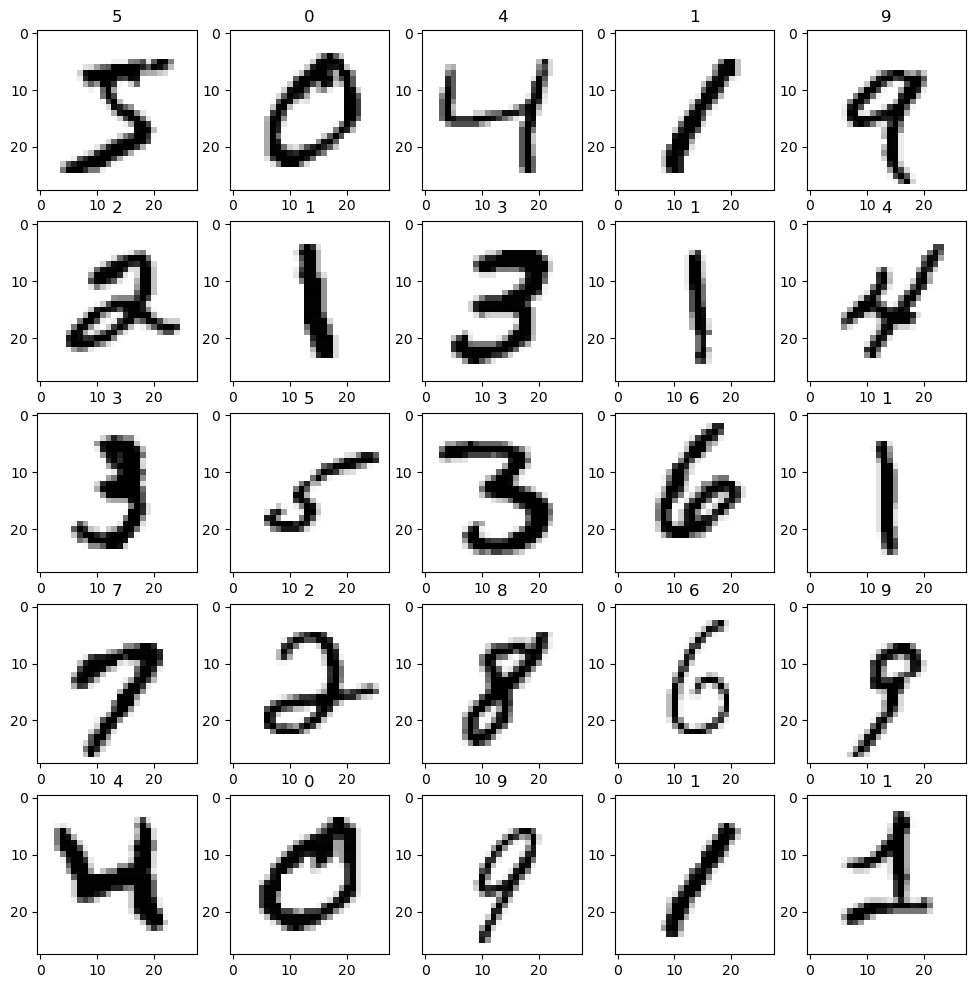

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5,5,figsize=(12,12))
for i in range(25):
    axes[i//5, i%5].imshow(x[i].reshape(28,-1),cmap = 'gray_r')
    axes[i//5, i%5].set_title(y[i])

In [40]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier(random_state=42)
# 학습
sgd.fit(x,y)

SGDClassifier(random_state=42)

In [41]:
sgd.score(x,y)

0.8976285714285714

In [42]:
sgd.predict(x[:25])

array(['3', '0', '4', '1', '9', '2', '1', '3', '1', '4', '3', '8', '3',
       '6', '1', '7', '2', '8', '6', '9', '4', '0', '9', '1', '3'],
      dtype='<U1')

In [43]:
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# skf = StratifiedKFold(n_splits=5, shuffle=True)
# cross_val_score(SGDClassifier(random_state=42),x,y,cv=skf)
# score,score.mean()

In [44]:
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
x, y = mnist['data'], mnist['target']
from sklearn.model_selection import cross_val_predict
import numpy as np

y_5 = (y == '5')

In [45]:
y_train_pred = cross_val_predict(SGDClassifier(random_state=42),x,y_5,cv=3)
y_train_pred

array([ True, False, False, ..., False,  True, False])

In [47]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_5, y_train_pred)
print(cm)
print(f'TN  5가 아님을 잘 맞춤 : {cm[0,0]} {cm[0,0] / len(y_5):.2f} ')
print(f'FP  모델이 5라고 예측했는데 아님...(5라고 억지부림) : {cm[0,1]} {cm[0,1] / len(y_5):.2f}')
print(f'FN  모델이 진짜 5를 놓침 : {cm[1,0]} {cm[1,0] / len(y_5):.2f}')
print(f'TP  5를 잘 맞춤 : {cm[1,1]} {cm[1,1] / len(y_5):.2f}')
print(f'정확도 : {(cm[0,0] + cm[1,1]) / len(y_5)}')

[[61910  1777]
 [ 1073  5240]]
TN  5가 아님을 잘 맞춤 : 61910 0.88 
FP  모델이 5라고 예측했는데 아님...(5라고 억지부림) : 1777 0.03
FN  모델이 진짜 5를 놓침 : 1073 0.02
TP  5를 잘 맞춤 : 5240 0.07
정확도 : 0.9592857142857143


AttributeError: 'Axes' object has no attribute 'set_xticklables'

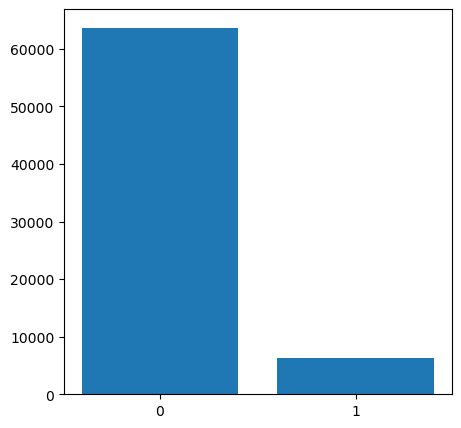

In [ ]:
import matplotlib.pylab as plt
import pandas as pd
fig, ax =  plt.subplots(figsize=(5,5))
data = pd.Series(y_5).value_counts()
ax.bar(data.index, data.values)
ax.set_xticks([0,1])
ax.set_xtickslables(['False','True'])
plt.tight_layout()